# Who: Jacopo

**Task:** Make text-classifier on the consult texts with agenda codes as labels

*Ingredients*: 
* probably best to use a trusted CNN but I know that you want to use a transformer so..just follow the recipe you can probably find online ;)
* Your text column:  ```text```, contains a concatenation of ```SpecialismeNaam, title, section_title_display_original, section_text```
* The target variable: use the target value you extracted from the afspraken set
* for the training use cross-validation: we are interested firstly in the performance on the test-sets, AND we are interested in **inspecting** the samples in the test-set that are high confidence false negative (potentially patients that should be included) and high confidence false negatives. 


In [2]:
import pandas as pd
from   transformers import AutoTokenizer, AutoModelForMaskedLM
import matplotlib.pyplot as plt
import os

In [3]:
df_consult_text = pd.read_parquet(r"T:\lab_research\RES-Folder-UPOD\ODIN-UC4\E_ResearchData\2_ResearchData\20240826\consult_texts.parquet")

In [4]:
os.chdir(r'T:\lab_research\RES-Folder-UPOD\ODIN-UC4\E_ResearchData\2_ResearchData\20240805')
df_afsprak = pd.read_sas('afspraken_20240805.sas7bdat', encoding='latin1')
df_afsprak.studyId_0831 = df_afsprak.studyId_0831.astype('uint64')
df_afsprak = df_afsprak.drop(['AfspCode', 'Agenda', 'period_start',\
       'period_end', 'Spec_Code', 'Specialisme', 'AgendaNaam', 'AgendaComment',\
       'AgendaKostenplaats', 'Description', 'AfspraakNummer', 'SubAgenda',\
       'serviceProv_Org_value', 'AfspraakStatus', 'status_code_original',\
       'status_display_original', 'type1_code', 'type1_display',\
       'type1_system', 'type2_code', 'type2_display', 'type2_system',\
       'type3_code', 'type3_display', 'type3_system', 'index_date'],axis='columns')
df_afsprak = df_afsprak.groupby('studyId_0831', sort=True).agg(lambda x: x.to_list())


In [5]:
def isEligible(x:pd.Series):
    if 'NFALG' in x or 'NFGEH' in x or 'NFVMI+' in x or 'NFVAL+' in x:
        return 1
    else:
        return 0

In [6]:
df_afsprak['label'] = df_afsprak.index_AfspCode.apply(isEligible)
df_afsprak = df_afsprak[['label']]
df_afsprak

,label
studyId_0831,
7992019,1
9812359,0
22291801,0
29822615,0
42120023,0
...,...
67374258279,1
67384735347,1
67387668117,0


In [7]:
df_consult = pd.read_sas(
    r'T:\lab_research\RES-Folder-UPOD\ODIN-UC4\E_ResearchData\2_ResearchData\20240822\consult_20240822.sas7bdat',
        encoding='latin1')
df_consult.studyId_0831 = df_consult.studyId_0831.astype('uint64')

In [8]:
df_consult = df_consult.drop(['Consult_id', 'ConsultStatus', 'type_code_original',
                              'type_display_original','created', 'title', 'author_usercode',
                              'initial_author_usercode', 'custodian_Organization_value',
                              'SpecialismeNaam', 'initial_custodian_Organization_v',
                              'SpecialismeNaamInitial', 'LocationCode', 'LocationName',
                              'PatientProtected', 'section_title_code_original',
                              'section_title_display_original', 'section_text',
                              'section_text_contentType', 'orderedBy', 'index_date'],axis='columns')
df_consult = df_consult.groupby('studyId_0831').last()
df_consult

,date
studyId_0831,
7992019,2022-05-06 15:38:00
9812359,2022-01-04 14:39:00
22291801,2022-02-23 09:29:00
29822615,2023-09-05 09:16:00
42120023,2022-05-19 16:25:00
...,...
67374258279,2020-11-30 14:11:00
67384735347,2020-07-27 10:08:00
67387668117,2021-01-05 11:59:00


In [9]:
df_merged = pd.merge(df_consult_text, df_consult, right_index=True,left_on='studyId_0831',how='left')
df_merged

,studyId_0831,date_x,text,date_y
8761,7992019,2022-04-07 13:00:00,SpecialismeNaam: Geriatrie\nOnderwerp: Polikli...,2022-05-06 15:38:00
8762,7992019,2022-04-07 13:00:00,SpecialismeNaam: Geriatrie\nOnderwerp: Polikli...,2022-05-06 15:38:00
8763,7992019,2022-04-07 13:00:00,SpecialismeNaam: Geriatrie\nOnderwerp: Polikli...,2022-05-06 15:38:00
8764,7992019,2022-04-07 13:00:00,SpecialismeNaam: Geriatrie\nOnderwerp: Polikli...,2022-05-06 15:38:00
8765,7992019,2022-04-08 17:03:00,SpecialismeNaam: Geriatrie\nOnderwerp: Overige...,2022-05-06 15:38:00
...,...,...,...,...
23134,67395825937,2021-04-29 15:10:00,SpecialismeNaam: Geriatrie\nOnderwerp: Overige...,2021-04-29 15:10:00
23122,67414211371,2020-07-28 14:01:00,SpecialismeNaam: Geriatrie\nOnderwerp: Polikli...,2020-11-23 16:30:00
23123,67414211371,2020-07-28 14:01:00,SpecialismeNaam: Geriatrie\nOnderwerp: Samenva...,2020-11-23 16:30:00
23124,67414211371,2020-08-19 15:31:00,SpecialismeNaam: Geriatrie\nOnderwerp: Polikli...,2020-11-23 16:30:00


In [10]:
df_merged['delta'] = (df_merged.date_x - df_merged.date_y).dt.days
df_merged_filt = df_merged.query('delta >= -365 and delta <= 0')

In [11]:
indices = []
def take_longer_consult(x):
    all_consults = x.to_list()
    max_len = -1
    for i,c in enumerate(all_consults):
        if len(c) > max_len:
            tmp = c
            idx = i
            max_len = len(c)
    
    indices.append(x.index[idx])
    return tmp


In [12]:
df_merged_f_g = df_merged_filt[['studyId_0831','text']]\
                    .groupby('studyId_0831')\
                        .agg(take_longer_consult)

<Axes: >

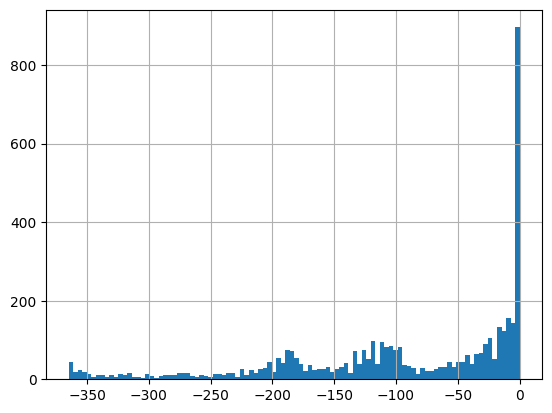

In [13]:
df_merged_filt['delta'].loc[indices].hist(bins=100)

In [14]:
df_merged_f_g['delta'] = df_merged_filt['delta'].loc[indices]

In [15]:
tokenizer = AutoTokenizer.from_pretrained("CLTL/MedRoBERTa.nl")
model = AutoModelForMaskedLM.from_pretrained("CLTL/MedRoBERTa.nl")

In [16]:
df_cooked = pd.DataFrame(columns=['ids'])

def to_ids(text):
    return tokenizer(text,return_attention_mask=False,return_tensors='pt',padding=True)['input_ids']

In [17]:
df_cooked['ids'] = df_merged_f_g.text.apply(to_ids)
df_cooked['id_len'] = df_cooked['ids'].apply(lambda x: x.shape[1])
df_cooked

,ids,id_len
studyId_0831,,
7992019,"[[tensor(0), tensor(14503), tensor(22082), ten...",2661
9812359,"[[tensor(0), tensor(14503), tensor(22082), ten...",1714
22291801,"[[tensor(0), tensor(14503), tensor(22082), ten...",1971
29822615,"[[tensor(0), tensor(14503), tensor(22082), ten...",1635
42120023,"[[tensor(0), tensor(14503), tensor(22082), ten...",585
...,...,...
67374258279,"[[tensor(0), tensor(14503), tensor(22082), ten...",1446
67384735347,"[[tensor(0), tensor(14503), tensor(22082), ten...",2144
67387668117,"[[tensor(0), tensor(14503), tensor(22082), ten...",1352


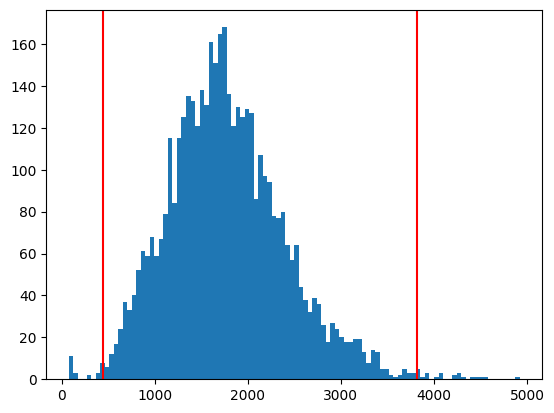

In [18]:
m = 0.005
M = 1-m
plt.hist(df_cooked['id_len'],bins=100)
plt.axvline(df_cooked['id_len'].quantile(m),color='red')
plt.axvline(df_cooked['id_len'].quantile(M),color='red')

In [19]:
q_min = df_cooked['id_len'].quantile(m)
q_max = df_cooked['id_len'].quantile(M)
df_cooked.query('id_len > @q_min and id_len < @q_max')

,ids,id_len
studyId_0831,,
7992019,"[[tensor(0), tensor(14503), tensor(22082), ten...",2661
9812359,"[[tensor(0), tensor(14503), tensor(22082), ten...",1714
22291801,"[[tensor(0), tensor(14503), tensor(22082), ten...",1971
29822615,"[[tensor(0), tensor(14503), tensor(22082), ten...",1635
42120023,"[[tensor(0), tensor(14503), tensor(22082), ten...",585
...,...,...
67374258279,"[[tensor(0), tensor(14503), tensor(22082), ten...",1446
67384735347,"[[tensor(0), tensor(14503), tensor(22082), ten...",2144
67387668117,"[[tensor(0), tensor(14503), tensor(22082), ten...",1352


In [20]:
df_cooked = df_cooked.reset_index()
#


In [21]:
df_cooked_labels = pd.merge(df_cooked, df_afsprak, right_index=True,left_on='studyId_0831',how='left')

---

Be careful uncommenting here, dataset generation code chunk...

In [22]:
#df_cooked_labels
#generate_dataset(df_cooked_labels, path=r'C:\Users\jvitale\text_dataset')

---

In [25]:
#import torch
#from transformers import AutoModelForCausalLM, AutoTokenizer
#
#
#device = 'cuda' if torch.cuda.is_available() else 'cpu'
#
#model_name = 'Rijgersberg/GEITje-7B-chat-v2'
#model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.bfloat16,
#                                             low_cpu_mem_usage=True, use_flash_attention_2=True,
#                                             device_map=device)
#tokenizer = AutoTokenizer.from_pretrained(model_name)
#
#def generate(conversation, temperature=0.2, top_k=50, max_new_tokens=1_000):
#    tokenized = tokenizer.apply_chat_template(conversation, add_generation_prompt=True,
#                                              return_tensors='pt').to(device)
#    outputs = model.generate(tokenized, do_sample=True, temperature=temperature,
#                             top_k=top_k, max_new_tokens=max_new_tokens)
#
#    return tokenizer.decode(outputs[0], skip_special_tokens=True)
#
#conversation = [
#    {
#        'role': 'user',
#        'content': 'Welk woord hoort er niet in dit rijtje thuis: "auto, vliegtuig, geitje, bus"?'
#    }
#]
#print(generate(conversation))
## <|user|>
## Welk woord hoort er niet in dit rijtje thuis: "auto, vliegtuig, geitje, bus"? 
## <|assistant|>
## Het woord dat niet op zijn plaats staat is 'geit'. Een geit zou niet tussen een lijst van vervoersmiddelen moeten staan. Het past beter bij een boerderijthema of dierenlijst.